In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()

Saving day.csv to day.csv
Saving hour.csv to hour.csv


In [3]:
df1=pd.read_csv("day.csv")
df2=pd.read_csv("hour.csv")

In [4]:
print("Day Dataset:")
df1.head()

Day Dataset:


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [5]:
print("\nHour Dataset:")
df2.head()


Hour Dataset:


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [6]:
def clean_data(df):
    df = df.copy()
    df = df.drop(columns=["instant", "dteday", "casual", "registered", "yr"], errors='ignore')
    df = df.drop_duplicates()
    df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)

    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="ignore")

    for col in df.select_dtypes(include=np.number).columns:
        df[col] = df[col].fillna(df[col].mean())

    for col in df.select_dtypes(include='object').columns:
        if df[col].mode().size > 0:
            df[col] = df[col].fillna(df[col].mode()[0])

    return df


def remove_outliers_iqr(df):
    df_cleaned = df.copy()
    numeric_cols = df_cleaned.select_dtypes(include=np.number).columns

    skip_cols = ["holiday", "workingday", "season"]
    numeric_cols = [col for col in numeric_cols if col not in skip_cols]

    for col in numeric_cols:
        Q1 = df_cleaned[col].quantile(0.25)
        Q3 = df_cleaned[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df_cleaned = df_cleaned[(df_cleaned[col] >= lower) & (df_cleaned[col] <= upper)]

    return df_cleaned



clean_day = clean_data(df1)
clean_hour = clean_data(df2)

print("Shape of clean_day before outlier removal:", clean_day.shape)
clean_day = remove_outliers_iqr(clean_day)
print("Shape of clean_day after outlier removal:", clean_day.shape)

print("\nShape of clean_hour before outlier removal:", clean_hour.shape)
clean_hour = remove_outliers_iqr(clean_hour)
print("Shape of clean_hour after outlier removal:", clean_hour.shape)

clean_day.to_csv("cleaned_day.csv", index=False)
clean_hour.to_csv("cleaned_hour.csv", index=False)


Shape of clean_day before outlier removal: (731, 11)
Shape of clean_day after outlier removal: (717, 11)

Shape of clean_hour before outlier removal: (17377, 12)


/tmp/ipython-input-3962142213.py:5: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)
/tmp/ipython-input-3962142213.py:8: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors="ignore")
/tmp/ipython-input-3962142213.py:5: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)
/tmp/ipython-input-3962142213.py:8: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors="ignore")


Shape of clean_hour after outlier removal: (16530, 12)


In [7]:
clean_day.head()

,season,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,985
1,1,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,801
2,1,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,1349
3,1,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,1562
4,1,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,1600


In [8]:
clean_hour.head()

,season,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,1,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,1,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,1,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,1,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1


In [9]:
def eda_summary(df, name="dataset"):
    print(f"\n\nEDA SUMMARY FOR: {name.upper()}")

    print("\nShape:", df.shape)
    print("\nColumns:", df.columns.tolist())

    print("\nData Types:")
    print(df.dtypes)

    print("\nMissing Values:")
    print(df.isnull().sum())

    print("\nDuplicate Rows:", df.duplicated().sum())

    print("\nStatistical Summary (Numeric):")
    display(df.describe())

    print("\nStatistical Summary (Categorical):")
    if not df.select_dtypes(include='object').empty:
        display(df.describe(include="object"))
    else:
        print("No categorical columns found for statistical summary.")

In [10]:
eda_summary(clean_day, "cleaned_day.csv")



EDA SUMMARY FOR: CLEANED_DAY.CSV

Shape: (717, 11)

Columns: ['season', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt']

Data Types:
season          int64
mnth            int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
cnt             int64
dtype: object

Missing Values:
season        0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64

Duplicate Rows: 0

Statistical Summary (Numeric):


,season,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
count,717.00000,717.000000,717.000000,717.000000,717.000000,717.000000,717.000000,717.000000,717.000000,717.000000,717.000000
mean,2.51325,6.562064,0.029289,2.995816,0.684798,1.396095,0.497365,0.476252,0.631562,0.186287,4532.843794
std,1.10555,3.439113,0.168732,2.001741,0.464921,0.543511,0.183617,0.163155,0.139222,0.071786,1933.542429
min,1.00000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.254167,0.022392,22.000000
25%,2.00000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337500,0.337939,0.524583,0.134329,3214.000000
50%,3.00000,7.000000,0.000000,3.000000,1.000000,1.000000,0.505833,0.491783,0.630833,0.178496,4570.000000
75%,3.00000,10.000000,0.000000,5.000000,1.000000,2.000000,0.656667,0.611121,0.732917,0.230721,6031.000000
max,4.00000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.378108,8714.000000



Statistical Summary (Categorical):
No categorical columns found for statistical summary.


In [11]:
eda_summary(clean_hour, "cleaned_hour.csv")



EDA SUMMARY FOR: CLEANED_HOUR.CSV

Shape: (16530, 12)

Columns: ['season', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt']

Data Types:
season          int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
cnt             int64
dtype: object

Missing Values:
season        0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64

Duplicate Rows: 0

Statistical Summary (Numeric):


,season,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
count,16530.000000,16530.000000,16530.000000,16530.000000,16530.000000,16530.000000,16530.000000,16530.000000,16530.000000,16530.000000,16530.000000,16530.000000
mean,2.505445,6.549304,11.418451,0.029643,2.992438,0.678524,1.427163,0.494162,0.473644,0.634017,0.182366,173.497459
std,1.108108,3.449789,6.979875,0.169606,2.012636,0.467057,0.637562,0.192689,0.171591,0.190103,0.112122,155.972743
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.080000,0.000000,1.000000
25%,2.000000,4.000000,5.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.490000,0.104500,37.000000
50%,3.000000,7.000000,11.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.640000,0.164200,136.000000
75%,3.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.640000,0.621200,0.790000,0.253700,267.000000
max,4.000000,12.000000,23.000000,1.000000,6.000000,1.000000,3.000000,1.000000,1.000000,1.000000,0.462700,645.000000



Statistical Summary (Categorical):
No categorical columns found for statistical summary.


In [12]:
def plot_distributions(df, name):
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

    print(f"\nGenerating distribution plots for {name}...")

    # Histograms
    for col in numeric_cols:
        plt.figure(figsize=(8, 5))
        sns.histplot(df[col], kde=True)
        plt.title(f'Histogram of {col} in {name}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.show()
        plt.close()

    # Boxplots
    for col in numeric_cols:
        plt.figure(figsize=(8, 5))
        sns.boxplot(y=df[col])
        plt.title(f'Boxplot of {col} in {name}')
        plt.ylabel(col)
        plt.show()
        plt.close()


Generating distribution plots for cleaned_day...


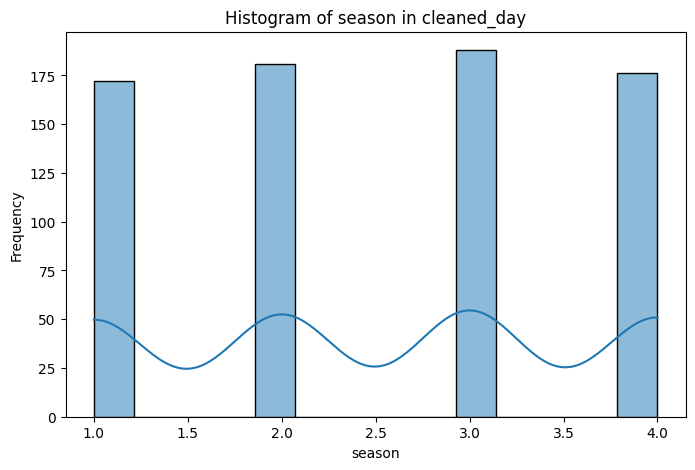

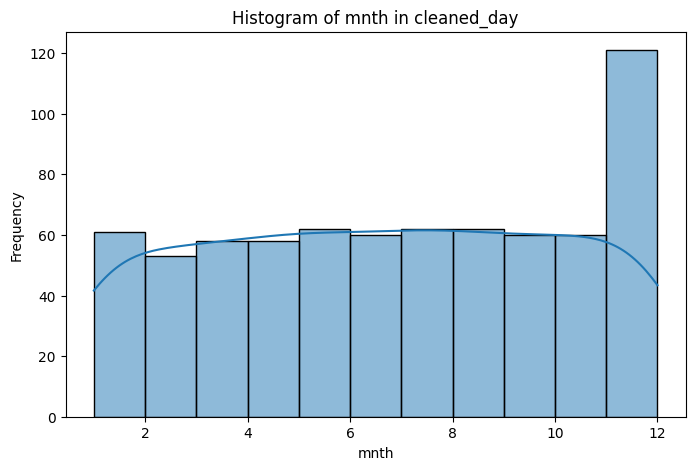

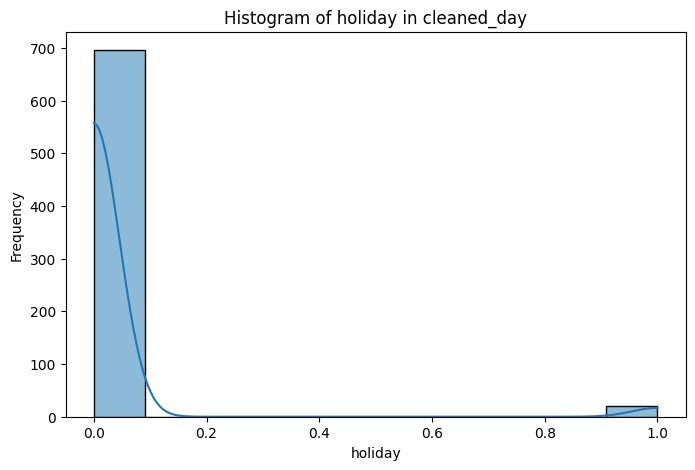

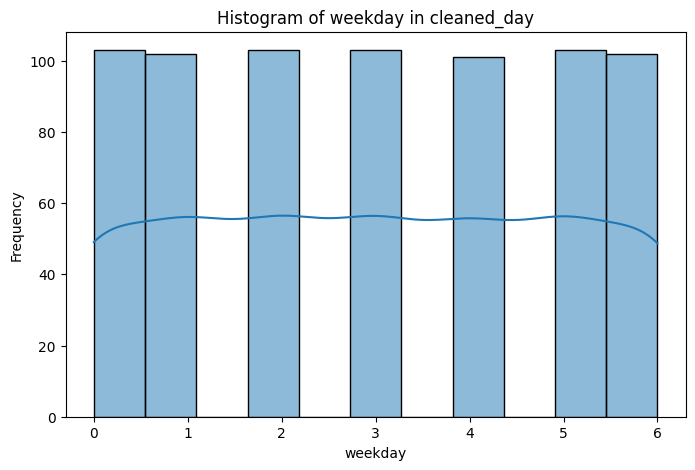

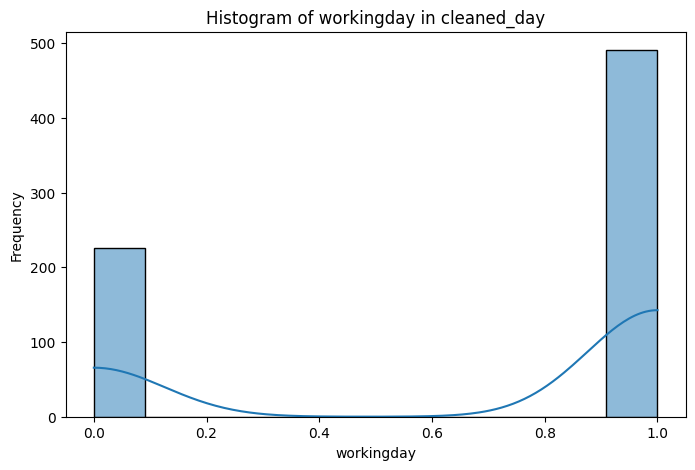

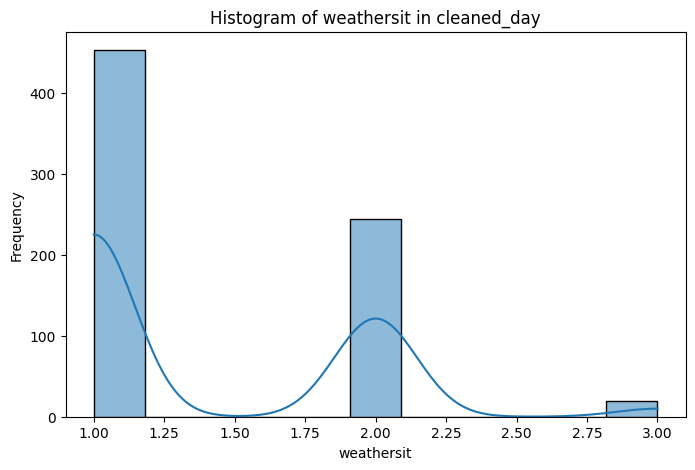

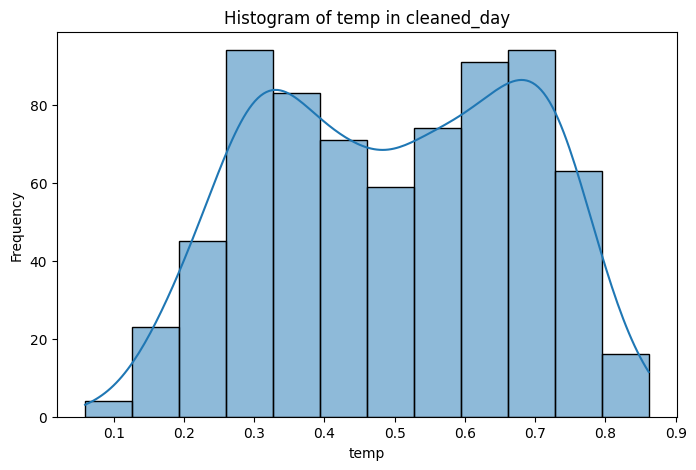

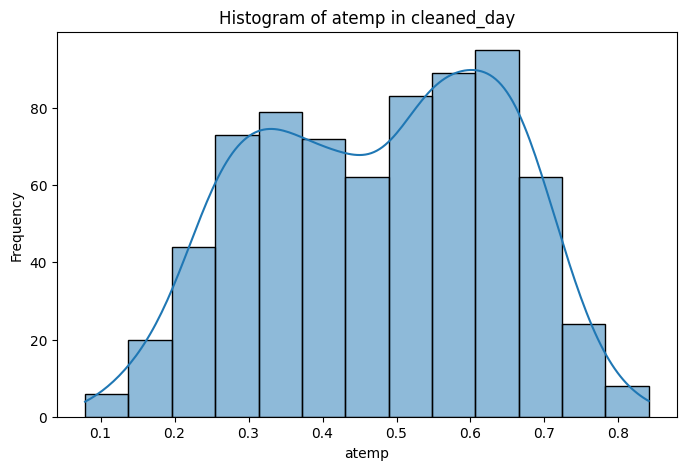

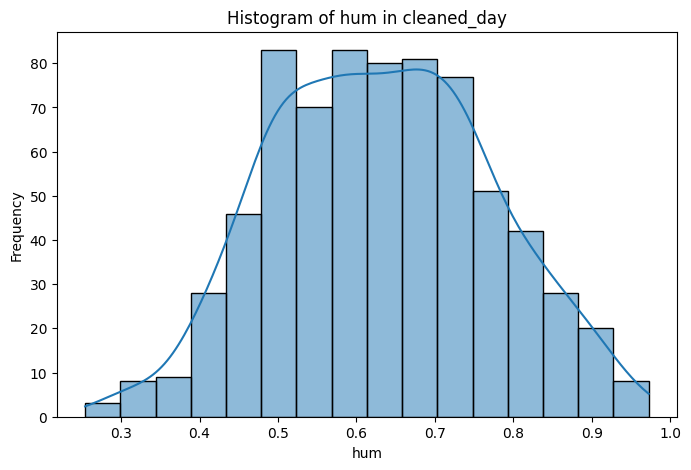

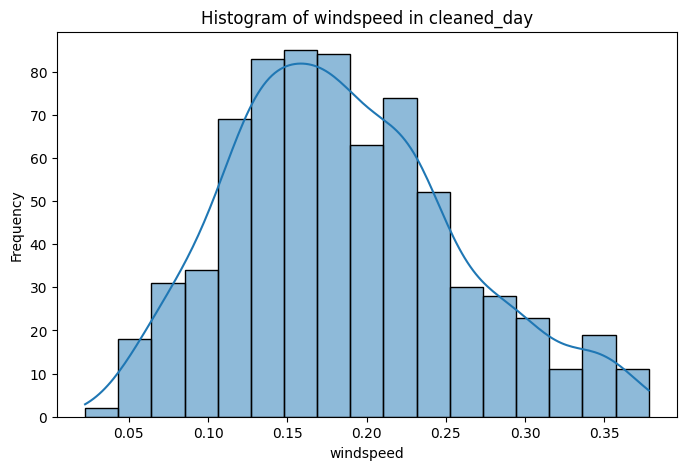

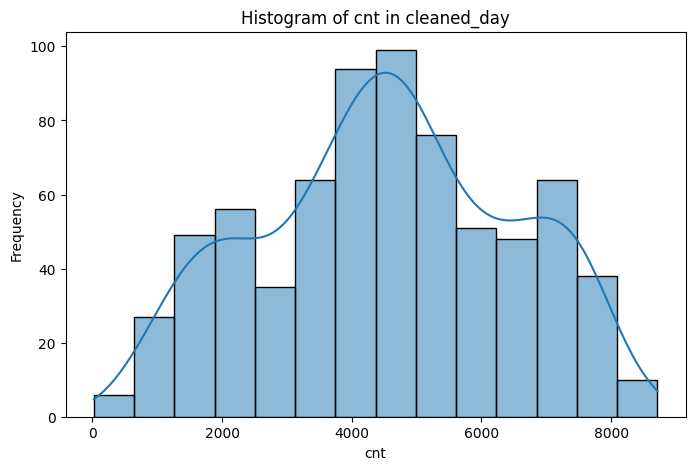

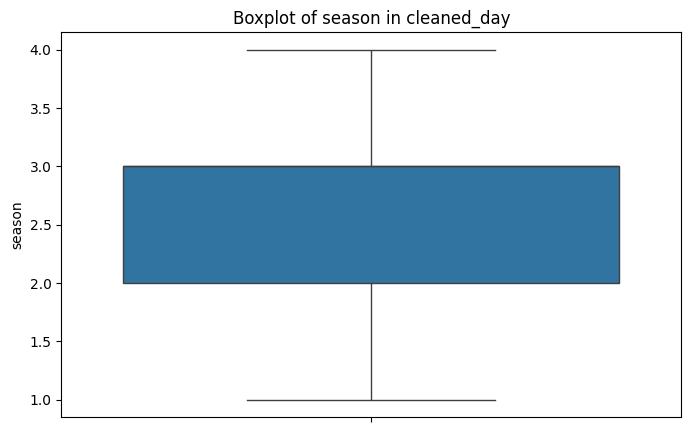

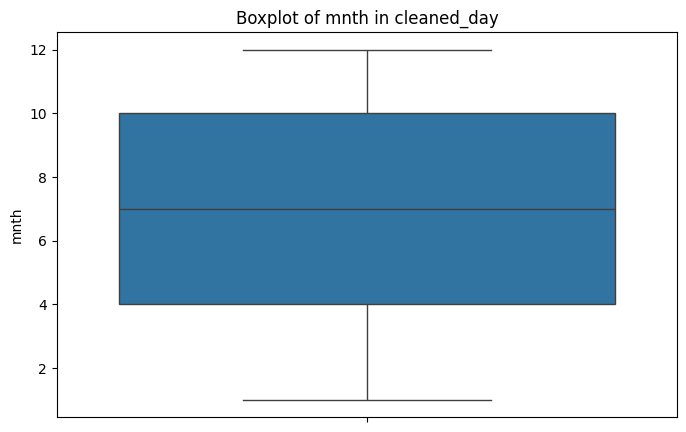

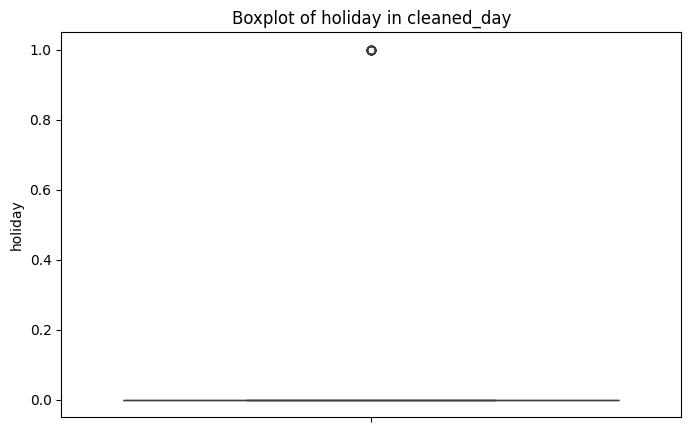

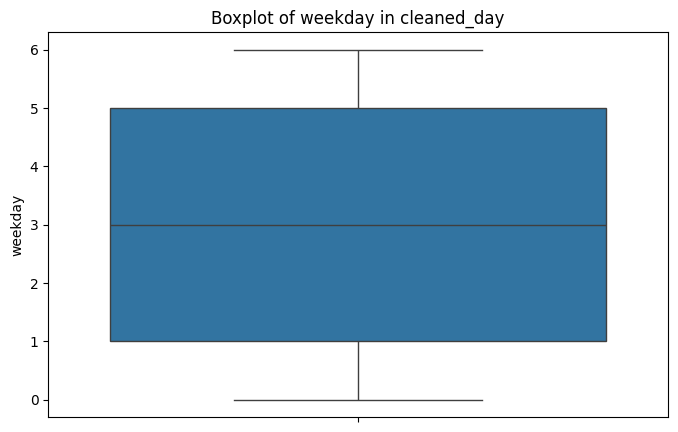

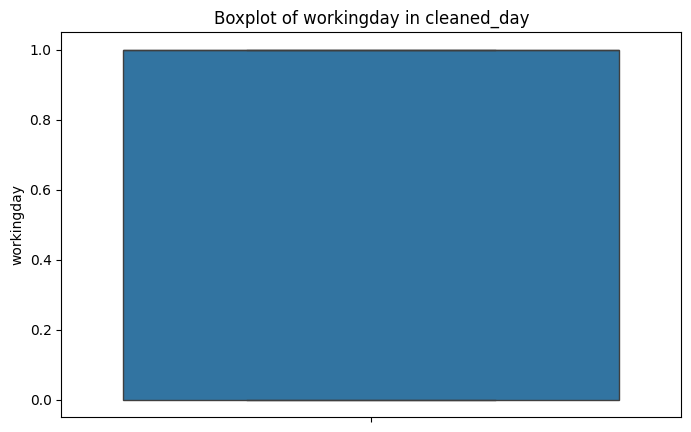

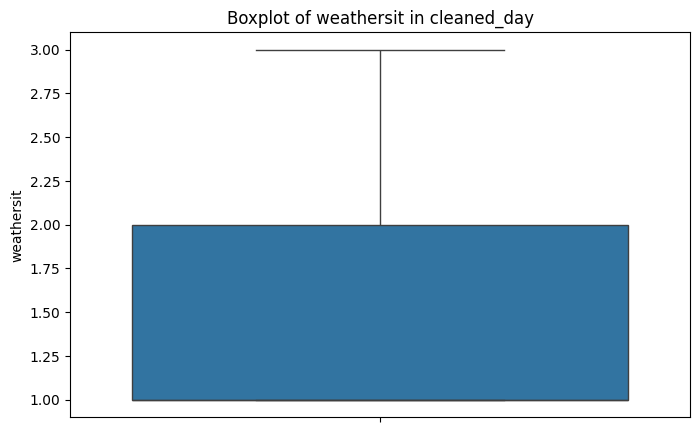

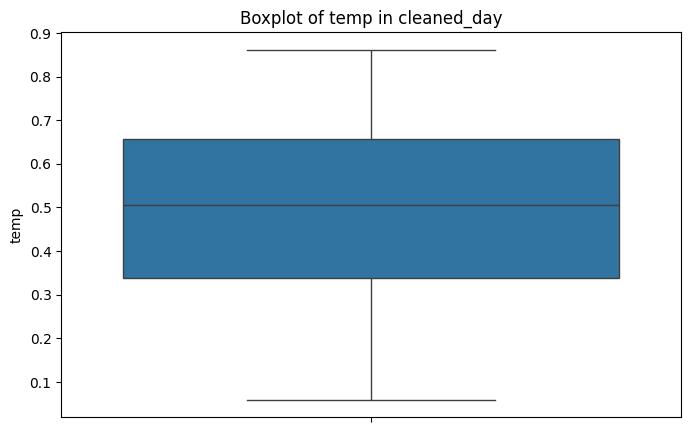

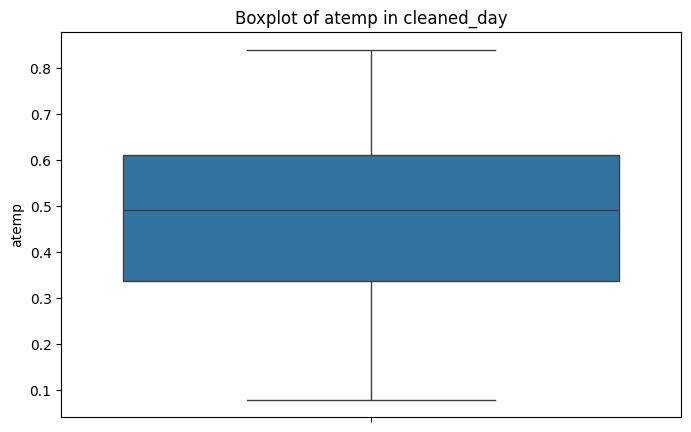

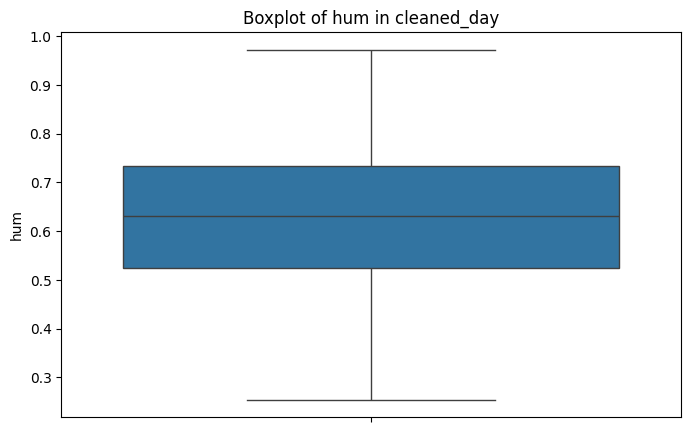

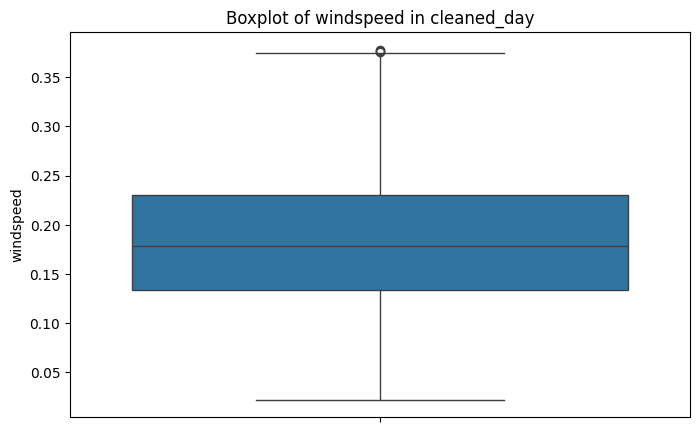

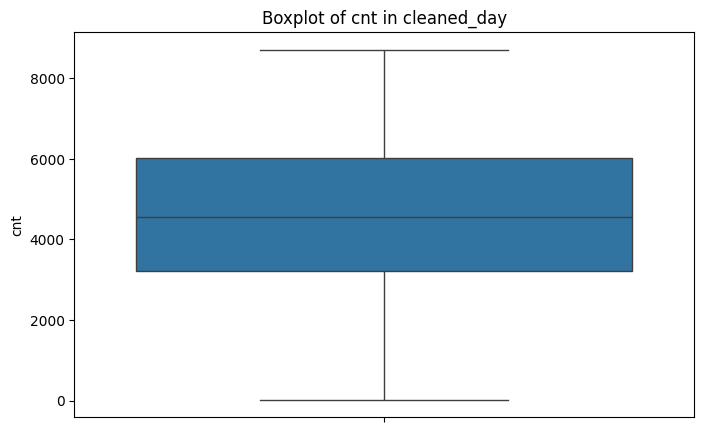

In [13]:
plot_distributions(clean_day, "cleaned_day")


Generating distribution plots for cleaned_hour...


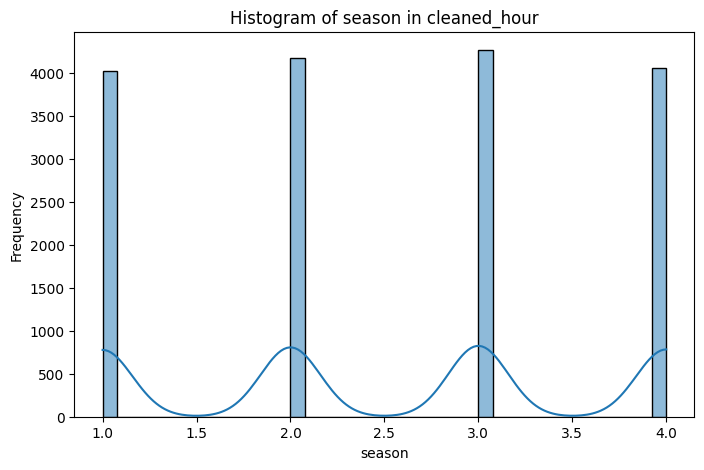

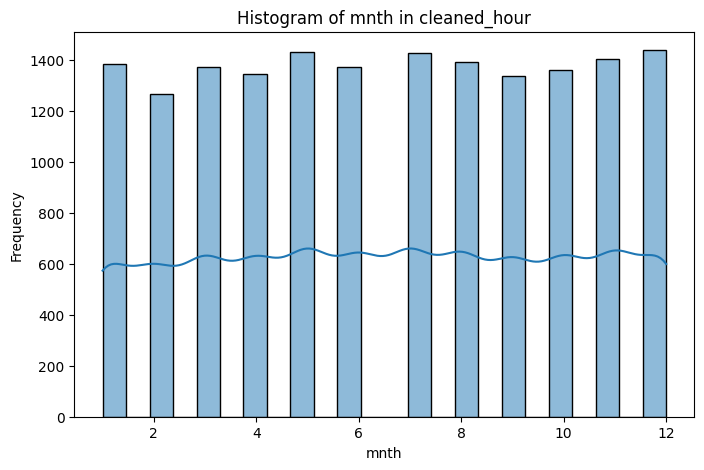

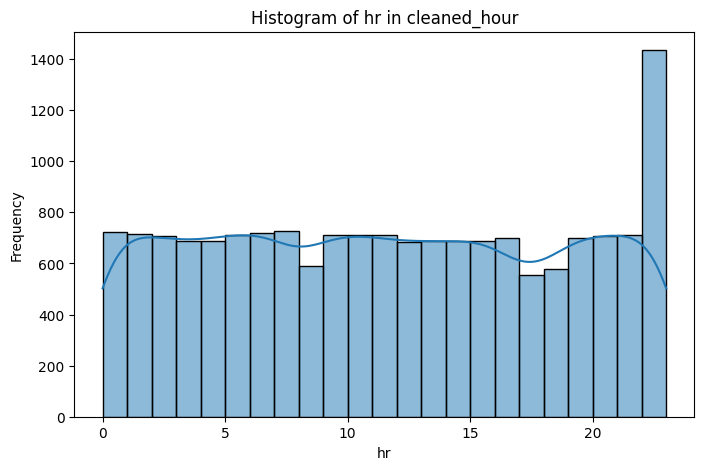

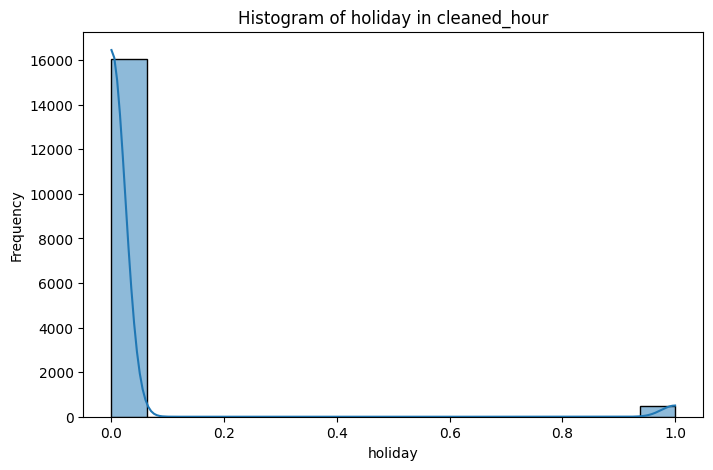

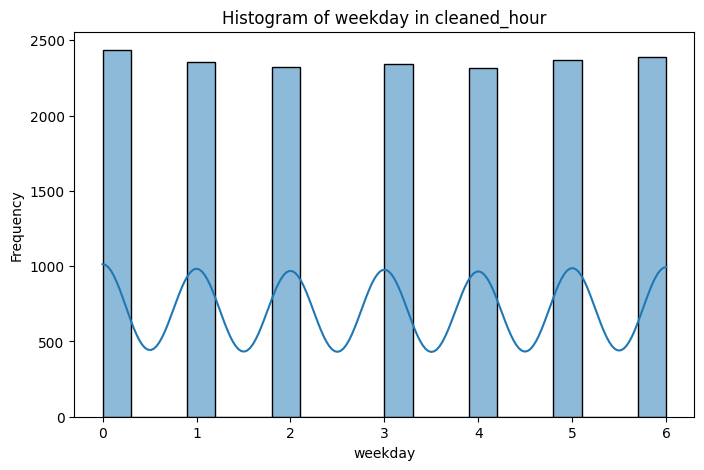

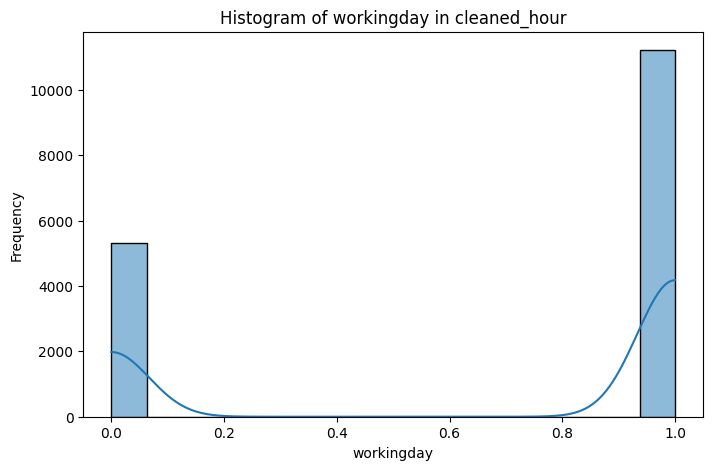

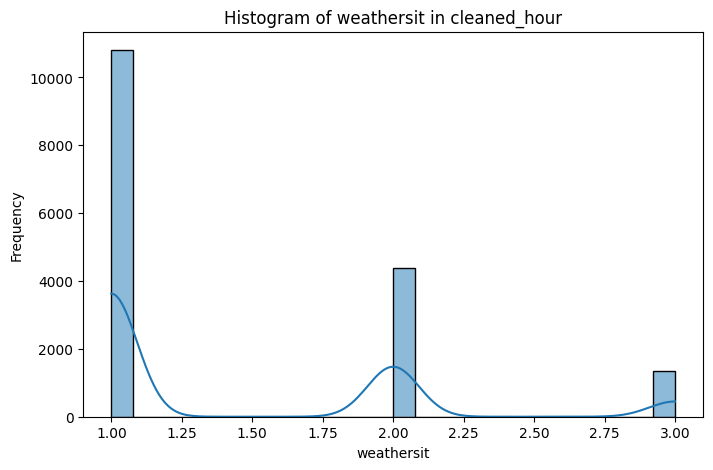

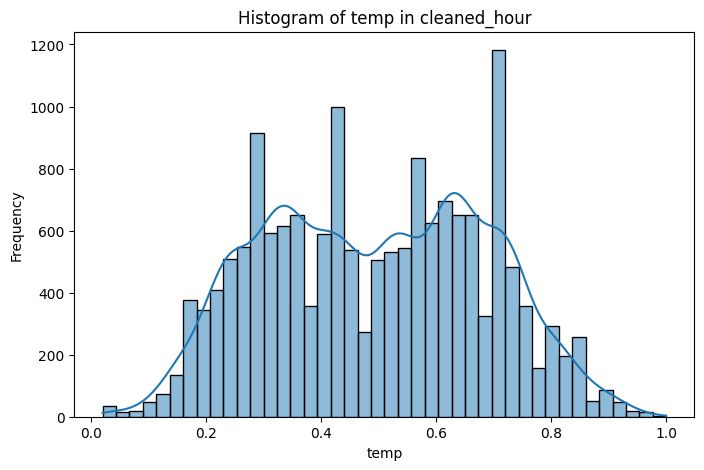

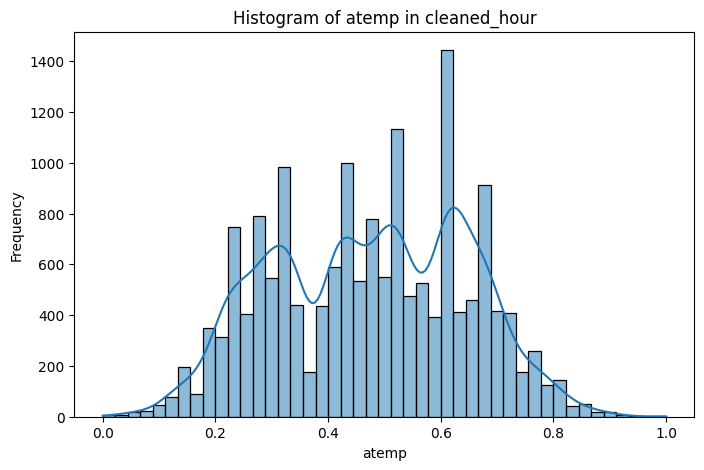

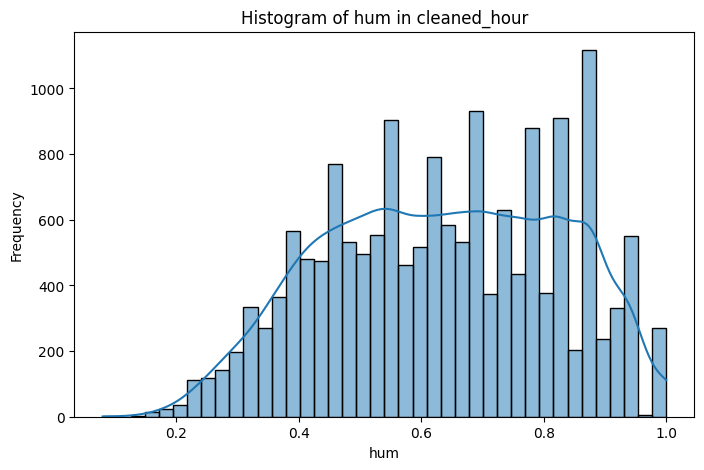

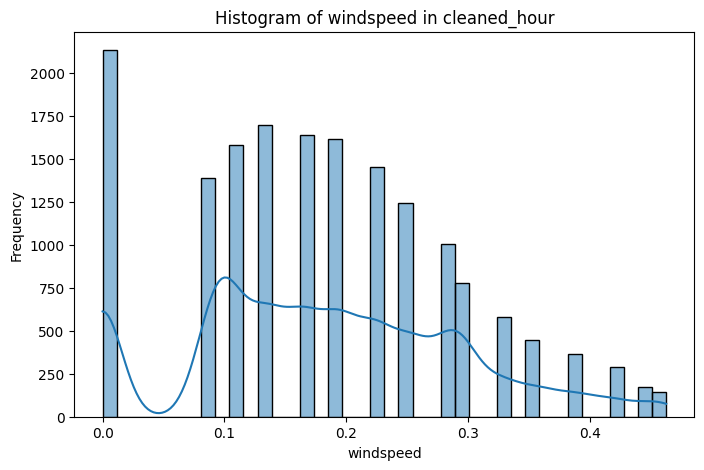

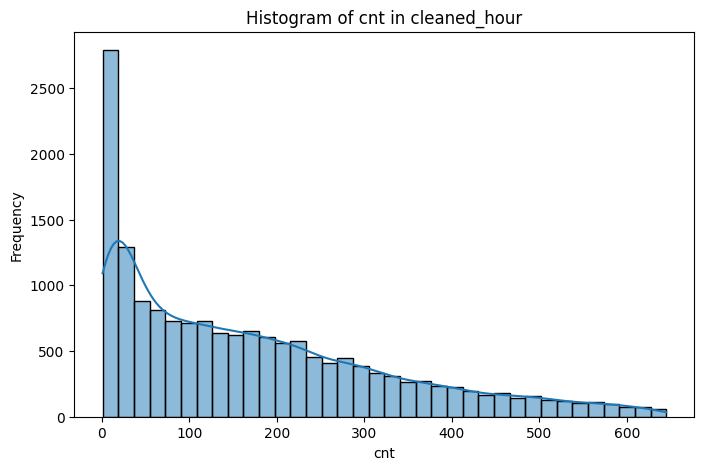

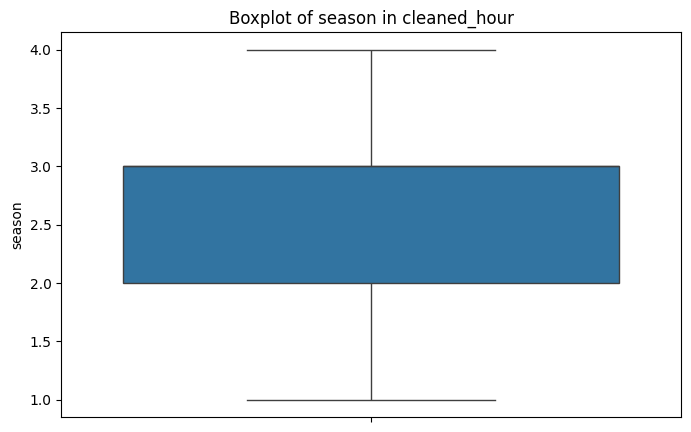

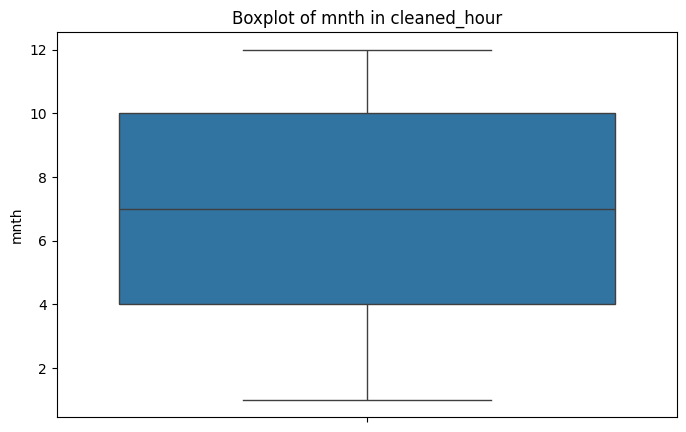

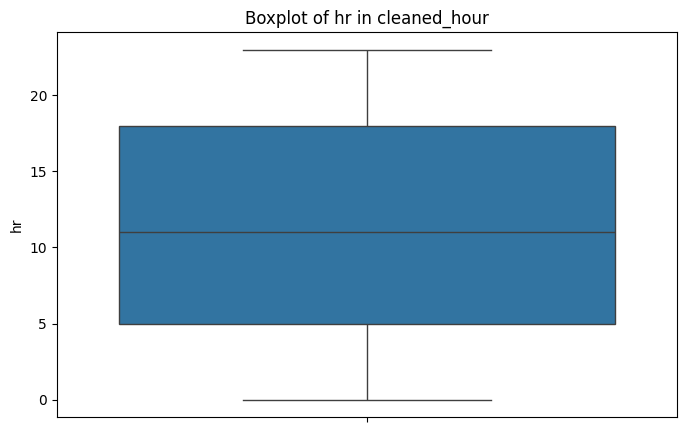

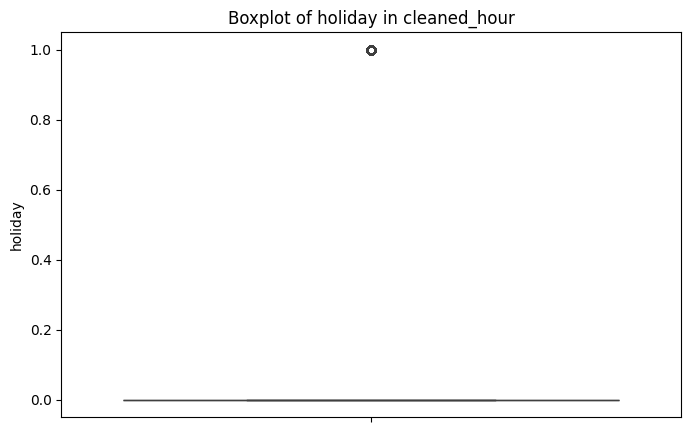

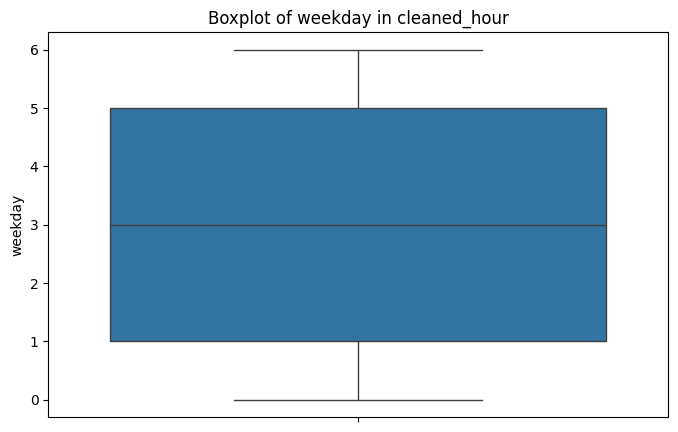

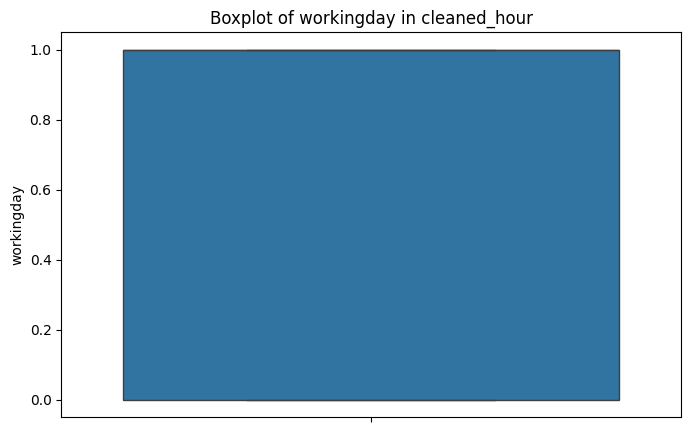

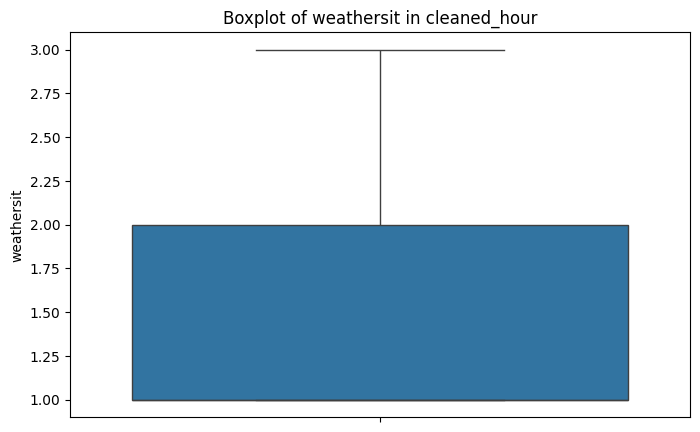

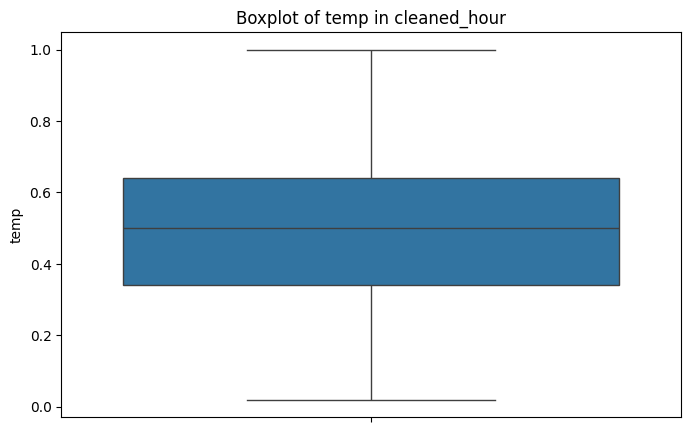

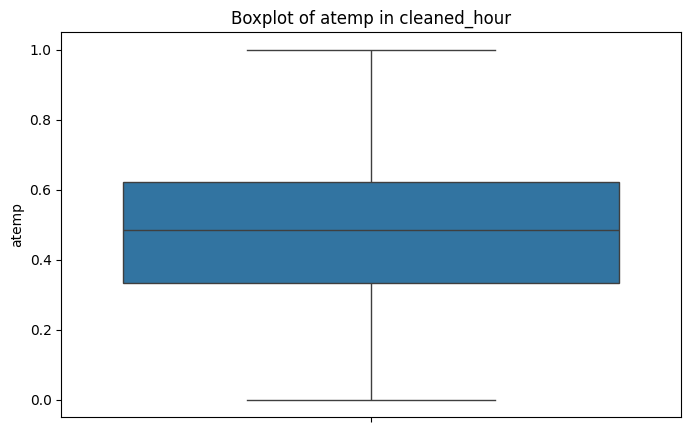

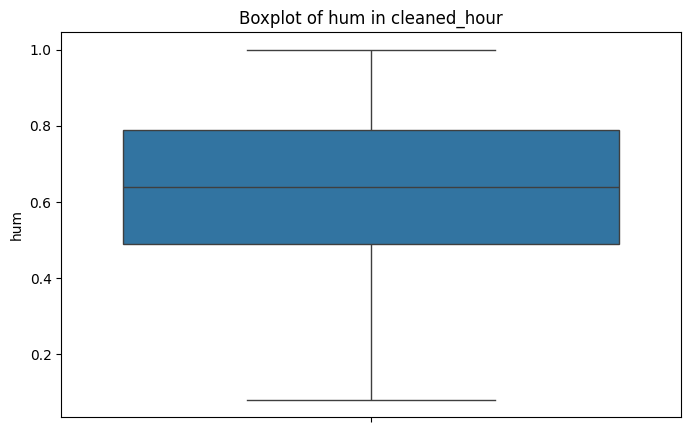

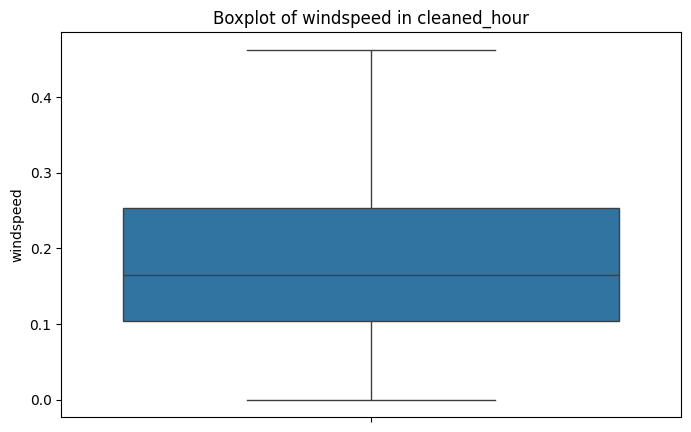

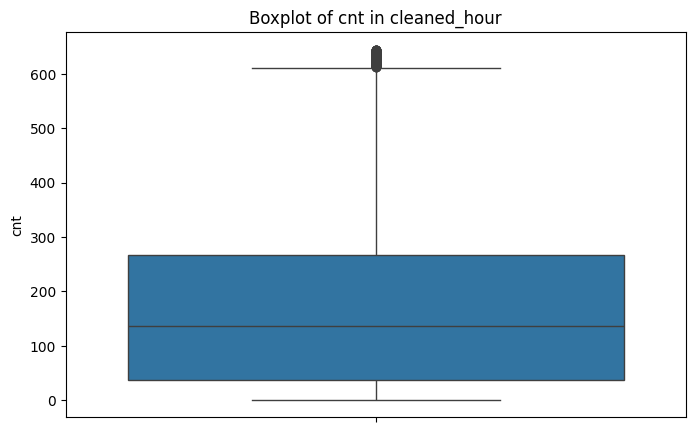

In [14]:
plot_distributions(clean_hour, "cleaned_hour")

In [15]:
def plot_correlation(df, name):
    plt.figure(figsize=(10, 8))
    sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
    plt.title(f"{name} Correlation Heatmap")
    plt.show()
    plt.close()

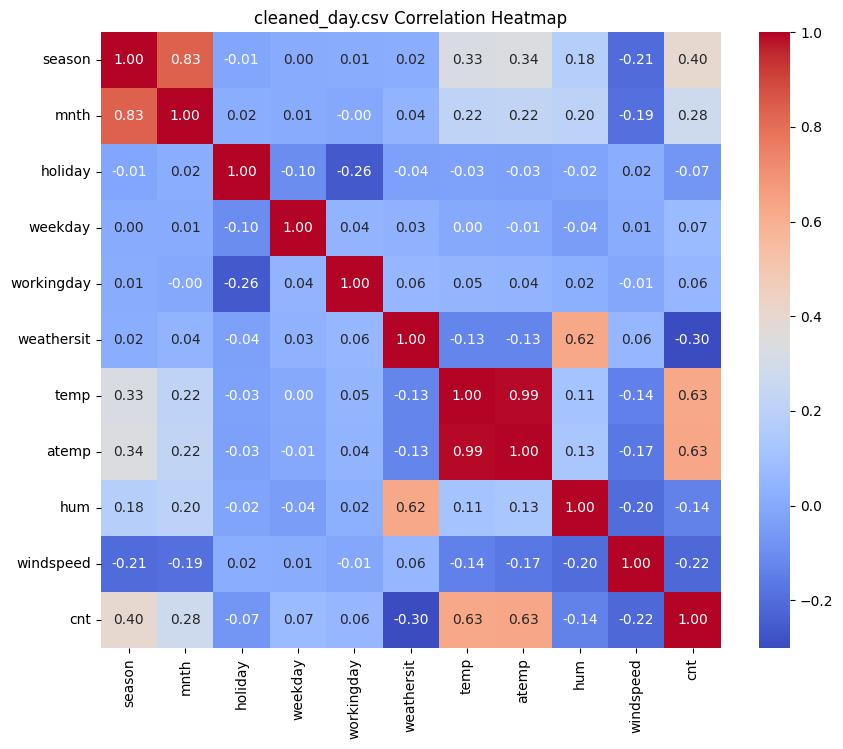

In [16]:
plot_correlation(clean_day, "cleaned_day.csv")

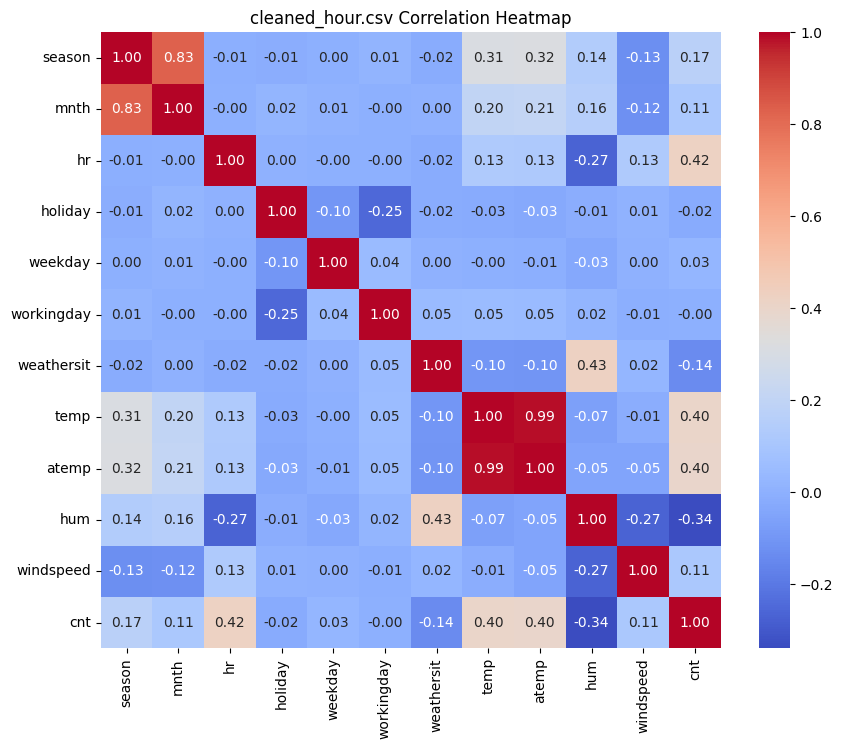

In [17]:
plot_correlation(clean_hour, "cleaned_hour.csv")

**Day Dataset**

In [18]:
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# Features & log-transformed target
X = clean_day.drop('cnt', axis=1)
y = np.log1p(clean_day['cnt'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

def evaluate(model, X_train, X_test, y_train, y_test):
    y_train_pred = np.expm1(model.predict(X_train))
    y_test_pred = np.expm1(model.predict(X_test))

    y_train_orig = np.expm1(y_train)
    y_test_orig = np.expm1(y_test)

    return {
        "Train_R2": r2_score(y_train_orig, y_train_pred),
        "Test_R2": r2_score(y_test_orig, y_test_pred),
        "Train_RMSE": np.sqrt(mean_squared_error(y_train_orig, y_train_pred)),
        "Test_RMSE": np.sqrt(mean_squared_error(y_test_orig, y_test_pred)),
        "Train_MAE": mean_absolute_error(y_train_orig, y_train_pred),
        "Test_MAE": mean_absolute_error(y_test_orig, y_test_pred)
    }


**Linear Regression**

In [19]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

param_grid = {
    'fit_intercept': [True, False],
    'positive': [True, False]
}

grid_lr = GridSearchCV(lr, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_lr.fit(X_train, y_train)

lr_best = grid_lr.best_estimator_
lr_metrics = evaluate(lr_best, X_train, X_test, y_train, y_test)

lr_metrics


{'Train_R2': 0.33560557161568616,
 'Test_R2': 0.49101565439613615,
 'Train_RMSE': np.float64(1570.9521198473415),
 'Test_RMSE': np.float64(1384.567111624939),
 'Train_MAE': 1247.7216015810016,
 'Test_MAE': 1086.9515462235138}

**Decision Tree Regressor**

In [20]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)

param_grid = {
    'max_depth': [4, 6, 8, 10],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [2, 4, 6]
}

grid_dt = GridSearchCV(dt, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_dt.fit(X_train, y_train)

dt_best = grid_dt.best_estimator_
dt_metrics = evaluate(dt_best, X_train, X_test, y_train, y_test)

dt_metrics


{'Train_R2': 0.7068158536107856,
 'Test_R2': 0.4811083181099203,
 'Train_RMSE': np.float64(1043.5666678759003),
 'Test_RMSE': np.float64(1397.9774081310557),
 'Train_MAE': 853.4170658577353,
 'Test_MAE': 1136.0975463104821}

**Random Forest Regressor**

In [21]:
from sklearn.ensemble import RandomForestRegressor

# Re-define X, y, and split for the day dataset explicitly here
X_day = clean_day.drop('cnt', axis=1)
y_day = np.log1p(clean_day['cnt'])
X_train_day, X_test_day, y_train_day, y_test_day = train_test_split(
    X_day, y_day, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(random_state=42)

param_dist = {
    'n_estimators': [300, 500, 700],
    'max_depth': [6, 8, 10],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [2, 4, 6],
    'max_features': ['sqrt', 'log2']
}

rs_rf = RandomizedSearchCV(
    rf, param_dist, n_iter=40, cv=5,
    scoring='r2', random_state=42, n_jobs=-1
)
rs_rf.fit(X_train_day, y_train_day)

rf_best_day = rs_rf.best_estimator_
rf_metrics_day = evaluate(rf_best_day, X_train_day, X_test_day, y_train_day, y_test_day)

rf_metrics_day

{'Train_R2': 0.8221250707248952,
 'Test_R2': 0.642761144857948,
 'Train_RMSE': np.float64(812.8442313269494),
 'Test_RMSE': np.float64(1159.9550050326245),
 'Train_MAE': 687.4968868626175,
 'Test_MAE': 972.1728396026231}

**Gradient Boosting Regressor**

In [22]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(random_state=42)

param_grid = {
    'n_estimators': [200, 300, 400],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [2, 3, 4]
}

grid_gbr = GridSearchCV(gbr, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_gbr.fit(X_train, y_train)

gbr_best = grid_gbr.best_estimator_
gbr_metrics = evaluate(gbr_best, X_train, X_test, y_train, y_test)

gbr_metrics


{'Train_R2': 0.8040753065803786,
 'Test_R2': 0.6377390935511158,
 'Train_RMSE': np.float64(853.0893999306298),
 'Test_RMSE': np.float64(1168.0798533864477),
 'Train_MAE': 698.7337577197502,
 'Test_MAE': 975.9442303684496}

**XGBoost Regressor**

In [23]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)

param_dist = {
    'n_estimators': [300, 400, 500],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [4, 6, 8],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

rs_xgb = RandomizedSearchCV(
    xgb, param_dist, n_iter=40, cv=5,
    scoring='r2', random_state=42, n_jobs=-1
)
rs_xgb.fit(X_train, y_train)

xgb_best = rs_xgb.best_estimator_
xgb_metrics = evaluate(xgb_best, X_train, X_test, y_train, y_test)

xgb_metrics


{'Train_R2': 0.8412817557838961,
 'Test_R2': 0.6350965111744269,
 'Train_RMSE': np.float64(767.8270059240142),
 'Test_RMSE': np.float64(1172.3325044452583),
 'Train_MAE': 629.8818855219072,
 'Test_MAE': 990.4489690992567}

**Comparison**

In [24]:
results = pd.DataFrame({
    "Linear": lr_metrics,
    "Decision Tree": dt_metrics,
    "Random Forest": rf_metrics_day,
    "Gradient Boosting": gbr_metrics,
    "XGBoost": xgb_metrics
}).T

results.sort_values("Test_R2", ascending=False)

,Train_R2,Test_R2,Train_RMSE,Test_RMSE,Train_MAE,Test_MAE
Random Forest,0.822125,0.642761,812.844231,1159.955005,687.496887,972.172840
Gradient Boosting,0.804075,0.637739,853.089400,1168.079853,698.733758,975.944230
XGBoost,0.841282,0.635097,767.827006,1172.332504,629.881886,990.448969
Linear,0.335606,0.491016,1570.952120,1384.567112,1247.721602,1086.951546
Decision Tree,0.706816,0.481108,1043.566668,1397.977408,853.417066,1136.097546


**Hour Dataset**

In [25]:
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# Features & log-transformed target (HOUR DATASET)
X = clean_hour.drop('cnt', axis=1)
y = np.log1p(clean_hour['cnt'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

def evaluate(model, X_train, X_test, y_train, y_test):
    y_train_pred = np.expm1(model.predict(X_train))
    y_test_pred = np.expm1(model.predict(X_test))

    y_train_orig = np.expm1(y_train)
    y_test_orig = np.expm1(y_test)

    return {
        "Train_R2": r2_score(y_train_orig, y_train_pred),
        "Test_R2": r2_score(y_test_orig, y_test_pred),
        "Train_RMSE": np.sqrt(mean_squared_error(y_train_orig, y_train_pred)),
        "Test_RMSE": np.sqrt(mean_squared_error(y_test_orig, y_test_pred)),
        "Train_MAE": mean_absolute_error(y_train_orig, y_train_pred),
        "Test_MAE": mean_absolute_error(y_test_orig, y_test_pred)
    }


**Linear Regression**

In [26]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

param_grid = {
    'fit_intercept': [True, False],
    'positive': [True, False]
}

grid_lr = GridSearchCV(lr, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_lr.fit(X_train, y_train)

lr_best = grid_lr.best_estimator_
lr_metrics = evaluate(lr_best, X_train, X_test, y_train, y_test)

lr_metrics


{'Train_R2': 0.15590696118950087,
 'Test_R2': 0.14682412988125448,
 'Train_RMSE': np.float64(143.7650367378829),
 'Test_RMSE': np.float64(142.0674030578681),
 'Train_MAE': 98.72972004536501,
 'Test_MAE': 96.32434810834218}

**Decision Tree Regressor**

In [27]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)

param_grid = {
    'max_depth': [6, 8, 10, 12],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [2, 4, 6]
}

grid_dt = GridSearchCV(dt, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_dt.fit(X_train, y_train)

dt_best = grid_dt.best_estimator_
dt_metrics = evaluate(dt_best, X_train, X_test, y_train, y_test)

dt_metrics


{'Train_R2': 0.8613805759764768,
 'Test_R2': 0.8101326179187396,
 'Train_RMSE': np.float64(58.25995774600628),
 'Test_RMSE': np.float64(67.01936998214421),
 'Train_MAE': 38.085644546758786,
 'Test_MAE': 44.18354119277741}

**Random Forest Regressor**

In [28]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

param_dist = {
    'n_estimators': [300, 500, 700],
    'max_depth': [8, 10, 12],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [2, 4, 6],
    'max_features': ['sqrt', 'log2']
}

rs_rf = RandomizedSearchCV(
    rf, param_dist, n_iter=40, cv=5,
    scoring='r2', random_state=42, n_jobs=-1
)

rs_rf.fit(X_train, y_train)

rf_best = rs_rf.best_estimator_
rf_metrics = evaluate(rf_best, X_train, X_test, y_train, y_test)

rf_metrics


{'Train_R2': 0.7692405023217834,
 'Test_R2': 0.7293654679249237,
 'Train_RMSE': np.float64(75.16885115998289),
 'Test_RMSE': np.float64(80.01414426900172),
 'Train_MAE': 45.7721953479051,
 'Test_MAE': 49.834711341530785}

**Gradient Boosting Regressor**

In [29]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(random_state=42)

param_grid = {
    'n_estimators': [300, 400, 500],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [2, 3, 4]
}

grid_gbr = GridSearchCV(gbr, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_gbr.fit(X_train, y_train)

gbr_best = grid_gbr.best_estimator_
gbr_metrics = evaluate(gbr_best, X_train, X_test, y_train, y_test)

gbr_metrics


{'Train_R2': 0.8877185599794907,
 'Test_R2': 0.8596630465592666,
 'Train_RMSE': np.float64(52.433893455561346),
 'Test_RMSE': np.float64(57.618398361737924),
 'Train_MAE': 34.39577199932555,
 'Test_MAE': 37.8679429854865}

**XGBoost Regressor**

In [30]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)

param_dist = {
    'n_estimators': [400, 600, 800],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [6, 8, 10],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

rs_xgb = RandomizedSearchCV(
    xgb, param_dist, n_iter=40, cv=5,
    scoring='r2', random_state=42, n_jobs=-1
)

rs_xgb.fit(X_train, y_train)

xgb_best = rs_xgb.best_estimator_
xgb_metrics = evaluate(xgb_best, X_train, X_test, y_train, y_test)

xgb_metrics


{'Train_R2': 0.9356457519635375,
 'Test_R2': 0.882895842550063,
 'Train_RMSE': np.float64(39.6959984844235),
 'Test_RMSE': np.float64(52.633386820251154),
 'Train_MAE': 25.251384788951725,
 'Test_MAE': 34.13100763856102}

**Comparison**

In [31]:
results_hour = pd.DataFrame({
    "Linear": lr_metrics,
    "Decision Tree": dt_metrics,
    "Random Forest": rf_metrics,
    "Gradient Boosting": gbr_metrics,
    "XGBoost": xgb_metrics
}).T

results_hour.sort_values("Test_R2", ascending=False)


,Train_R2,Test_R2,Train_RMSE,Test_RMSE,Train_MAE,Test_MAE
XGBoost,0.935646,0.882896,39.695998,52.633387,25.251385,34.131008
Gradient Boosting,0.887719,0.859663,52.433893,57.618398,34.395772,37.867943
Decision Tree,0.861381,0.810133,58.259958,67.019370,38.085645,44.183541
Random Forest,0.769241,0.729365,75.168851,80.014144,45.772195,49.834711
Linear,0.155907,0.146824,143.765037,142.067403,98.729720,96.324348


**Prediction for Day: Day1, Day2,...Day6**

In [32]:
model=results["Test_R2"].idxmax()
print(model)

Random Forest


In [33]:
future_days = pd.DataFrame({
    'season': [2]*6,
    'mnth': [7]*6,
    'holiday': [0]*6,
    'weekday': [1, 2, 3, 4, 5, 6],
    'workingday': [1, 1, 1, 1, 1, 0],
    'weathersit': [1, 1, 2, 1, 1, 2],
    'temp': [0.68, 0.69, 0.67, 0.66, 0.65, 0.64],
    'atemp': [0.66, 0.67, 0.65, 0.64, 0.63, 0.62],
    'hum': [0.55, 0.56, 0.58, 0.57, 0.59, 0.60],
    'windspeed': [0.18, 0.17, 0.19, 0.20, 0.18, 0.21]
})

In [34]:
preds = rf_best_day.predict(future_days)
cnt_preds = np.expm1(preds)
future_days['Predicted_Bike_Demand'] = cnt_preds.round().astype(int)
print(future_days)

   season  mnth  holiday  weekday  workingday  weathersit  temp  atemp   hum  \
0       2     7        0        1           1           1  0.68   0.66  0.55   
1       2     7        0        2           1           1  0.69   0.67  0.56   
2       2     7        0        3           1           2  0.67   0.65  0.58   
3       2     7        0        4           1           1  0.66   0.64  0.57   
4       2     7        0        5           1           1  0.65   0.63  0.59   
5       2     7        0        6           0           2  0.64   0.62  0.60   

   windspeed  Predicted_Bike_Demand  
0       0.18                   5605  
1       0.17                   5762  
2       0.19                   5559  
3       0.20                   5697  
4       0.18                   6056  
5       0.21                   5846  


In [35]:
prediction_output = future_days[['Predicted_Bike_Demand']]
prediction_output.index = [f"Day {i}" for i in range(1, 7)]
print(prediction_output)

       Predicted_Bike_Demand
Day 1                   5605
Day 2                   5762
Day 3                   5559
Day 4                   5697
Day 5                   6056
Day 6                   5846


**Prediction for Hour: Hour1, Hour2,...Hour6**

In [36]:
model_hr=results_hour["Test_R2"].idxmax()
print(model)

Random Forest


In [47]:
future_hours = pd.DataFrame({
    'season': [2]*6,
    'mnth': [7]*6,
    'hr': [1, 2, 3, 4, 5, 6],
    'holiday': [0]*6,
    'weekday': [2]*6,
    'workingday': [1]*6,
    'weathersit': [1, 1, 2, 1, 1, 2],
    'temp': [0.67, 0.66, 0.65, 0.64, 0.63, 0.62],
    'atemp': [0.65, 0.64, 0.63, 0.62, 0.61, 0.60],
    'hum': [0.58, 0.59, 0.60, 0.61, 0.62, 0.63],
    'windspeed': [0.18, 0.19, 0.20, 0.21, 0.20, 0.19]
})

In [48]:
preds = xgb_best.predict(future_hours)
cnt_preds = np.expm1(preds)
future_hours['Predicted_Bike_Demand'] = cnt_preds.round().astype(int)
print(future_hours)

   season  mnth  hr  holiday  weekday  workingday  weathersit  temp  atemp  \
0       2     7   1        0        2           1           1  0.67   0.65   
1       2     7   2        0        2           1           1  0.66   0.64   
2       2     7   3        0        2           1           2  0.65   0.63   
3       2     7   4        0        2           1           1  0.64   0.62   
4       2     7   5        0        2           1           1  0.63   0.61   
5       2     7   6        0        2           1           2  0.62   0.60   

    hum  windspeed  Predicted_Bike_Demand  
0  0.58       0.18                     15  
1  0.59       0.19                      8  
2  0.60       0.20                      4  
3  0.61       0.21                      5  
4  0.62       0.20                     28  
5  0.63       0.19                    122  


In [49]:
hourly_prediction = future_hours[['hr', 'Predicted_Bike_Demand']]
hourly_prediction.index = [f"Hour {i}" for i in range(1, 7)]
print(hourly_prediction)

        hr  Predicted_Bike_Demand
Hour 1   1                     15
Hour 2   2                      8
Hour 3   3                      4
Hour 4   4                      5
Hour 5   5                     28
Hour 6   6                    122
